### Final Model, Testing and Evaluation
>

- Expands this approach to other indices (qDL, qDN, qJN etc. from universal system).
- Integrates clinical covariates + tree indices in one predictive framework.
- Tests whether combining both sets of features improves prediction (e.g., C-index, KM stratification).
- Potentially generalizes beyond lung cancer to other tumour types.

In [113]:
# Load folder from GitHub
import os
!git clone https://github.com/szinja/cell-translation.git


Cloning into 'cell-translation'...
remote: Enumerating objects: 967, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 967 (delta 27), reused 48 (delta 14), pack-reused 903 (from 2)
Receiving objects: 100% (967/967), 70.90 MiB | 11.75 MiB/s, done.
Resolving deltas: 100% (322/322), done.
Updating files: 100% (852/852), done.


In [100]:
!git clone https://github.com/szinja/cell-translation.git
%cd cell-translation/data
%ls

Cloning into 'cell-translation'...
remote: Enumerating objects: 967, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 967 (delta 27), reused 48 (delta 14), pack-reused 903 (from 2)
Receiving objects: 100% (967/967), 70.90 MiB | 21.78 MiB/s, done.
Resolving deltas: 100% (322/322), done.
/content/cell-translation/data/cell-translation/data
20221109_TRACERx421_all_patient_df_Converted.csv  index_values.csv
20221109_TRACERx421_all_patient_df.csv            tracerX.csv
20221109_TRACERx421_all_patient_df.rds*           tree_features.csv


In [7]:
import pandas as pd
import re

# Load your index values
indices = pd.read_csv("index_values.csv")
clinical_data = pd.read_csv("tracerX.csv")

# Rename first column of indices to "cruk_id"
indices = indices.rename(columns={'Unnamed: 0': 'cruk_id'})

# Merge on "cruk_id"
df = pd.merge(indices, clinical_data, on="cruk_id")
print(df.head())



    cruk_id       D0N       D1N       J1N       D0L       D1L       J1L  \
0  CRUK0005  1.932627  1.742531  0.859629  2.179847  1.929729  0.840794   
1  CRUK0057  1.975607  1.916749  0.956365  1.993439  1.932488  0.955200   
2  CRUK0039  1.987617  1.985391  0.998383  1.999295  1.996384  0.997898   
3  CRUK0196  1.981054  1.779534  0.845231  1.995685  1.790370  0.843374   
4  CRUK0023  2.863853  2.692236  0.939676  2.894448  2.715595  0.936944   

        D0S       D1S       J1S  ... os_time cens_dfs  dfs_time  \
0  5.316530  4.474772  0.901049  ...     649        1       649   
1  2.051049  1.988137  0.956562  ...    2431        1      1268   
2  2.045360  2.032683  0.995254  ...    1155        1       935   
3  2.037383  1.827483  0.845745  ...       1        1         1   
4  3.080632  2.857888  0.939486  ...     994        1       316   

  cens_dfs_any_event dfs_time_any_event  cens_lung_event  lung_event_time  \
0                  1                649                0             

# Exploratory Analysis of indices with clinical data

In [8]:
print(clinical_data.columns)
print(clinical_data.head)

Index(['cruk_id', 'tumour_id_muttable_cruk', 'tumour_id_per_patient', 'age',
       'sex', 'ethnicity', 'cigs_perday', 'years_smoking', 'packyears',
       'smoking_status_merged', 'is.family.lung', 'ECOG_PS', 'pathologyTNM',
       'pT_stage_per_patient', 'pN_stage_per_patient', 'LVI_per_patient',
       'PL_per_patient', 'margin_status_per_patient',
       'size_pathology_per_patient', 'Surgery_type', 'histology_lesion1',
       'histology_lesion1_merged', 'lesion1_sampled', 'histology_lesion2',
       'lesion2_sampled', 'histology_multi_full',
       'histology_multi_full_genomically.confirmed', 'LUAD_pred_subtype',
       'adjuvant_treatment_YN', 'adjuvant_treatment_given',
       'num_cycle_na.added', 'CHMPlatDgName_cleaned', 'CHMOthDgName_cleaned',
       'AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'Recurrence_time_use',
       'newPrim_time_use', 'first_dfs_any_event_rec.or.new.primary',
       'first_event_during_followup', 'cens_os', 'os_time', 'cens_dfs',
       'dfs_ti

The tree-shape indices used (1DN, 1DL, 1JN).
* 1DN: effective out-degree (branching intensity)
* 1DL: effective number of maximally distinct leaves (diversity)
* 1JN: tree balance (symmetry of branching)

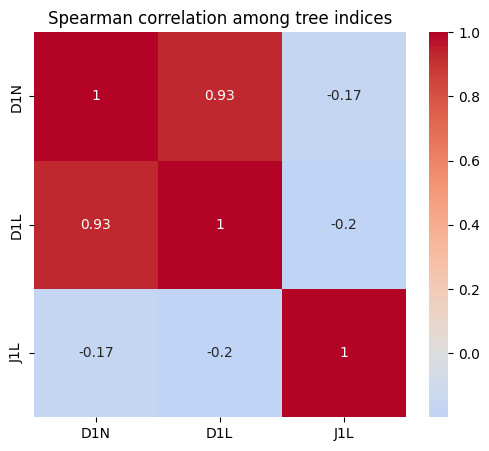

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only index columns
index_cols = ["D1N", "D1L", "J1L"] # lst: (D0N, D1N, J1N, D0L, D1L, J1L, D0S, D1S, J1S)
corr = df[index_cols].corr(method="spearman")

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman correlation among tree indices")
plt.show()

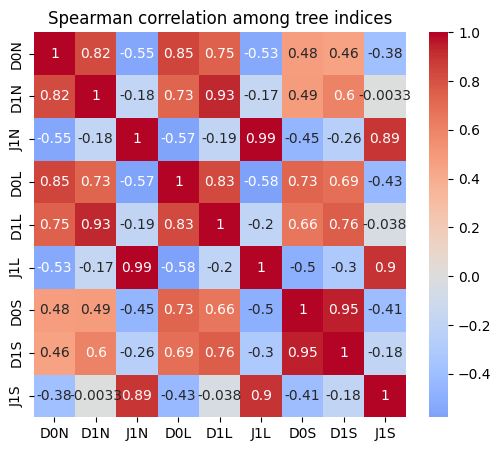

In [10]:
# Only index columns
index_cols = ["D0N", "D1N", "J1N", "D0L", "D1L", "J1L", "D0S", "D1S", "J1S"] # lst: (D0N, D1N, J1N, D0L, D1L, J1L, D0S, D1S, J1S)
corr = df[index_cols].corr(method="spearman")

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman correlation among tree indices")
plt.show()

In [11]:
# Indices with high correlation (over 80%)
import numpy as np

threshold = 0.8
high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) # keep only upper triangle
    .stack()  # reshape
    .reset_index()
)
high_corr_pairs.columns = ["Index1", "Index2", "Correlation"]

# Filter strong correlations
high_corr_pairs = high_corr_pairs.loc[high_corr_pairs["Correlation"].abs() >= threshold]

print(high_corr_pairs)

   Index1 Index2  Correlation
0     D0N    D1N     0.823554
2     D0N    D0L     0.845422
10    D1N    D1L     0.930965
17    J1N    J1L     0.990228
20    J1N    J1S     0.891181
21    D0L    D1L     0.829604
32    J1L    J1S     0.896481
33    D0S    D1S     0.949443


In [14]:
cutoff_days = int(3.5 * 365)

# Event = 1 if death occurred before cutoff, else 0
df["os_event"] = (df["os_time"] <= cutoff_days).astype(int)

# Optional: also create a label for clarity
df["os_event_label"] = df["os_event"].map({0: "Survived ≥3.5yr", 1: "Deceased <3.5yr"})

# Quick check
print(df[["os_time", "os_event", "os_event_label"]].head())


   os_time  os_event   os_event_label
0      649         1  Deceased <3.5yr
1     2431         0  Survived ≥3.5yr
2     1155         1  Deceased <3.5yr
3        1         1  Deceased <3.5yr
4      994         1  Deceased <3.5yr


Mann–Whitney U test (non-parametric, robust to non-normality, good for small N).

* Small U-value: A small U-value means that many values from one group consistently rank lower than values from the other group, suggesting the groups are different.
* Large U-value: A large U-value (closer to the maximum possible) would suggest no difference between the groups.


/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


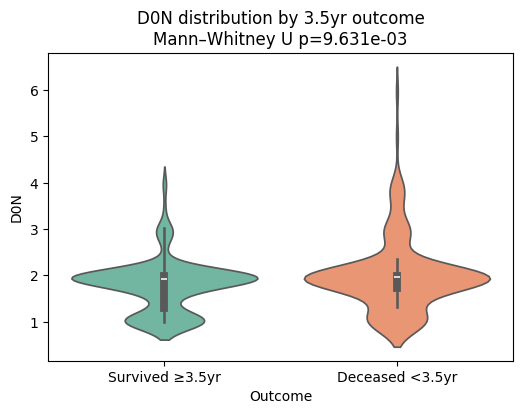

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


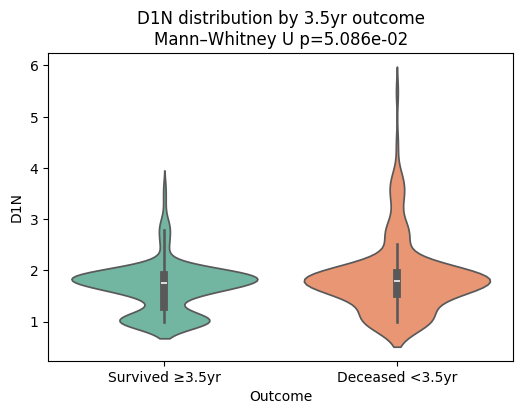

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


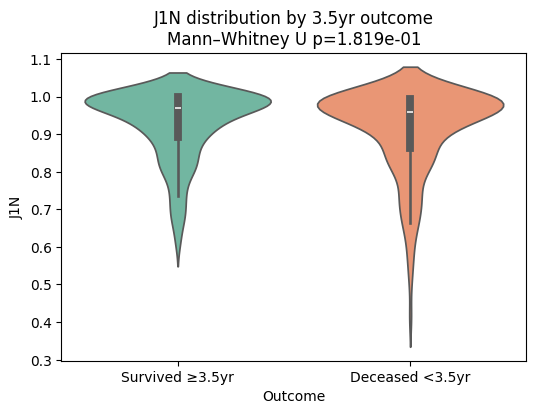

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


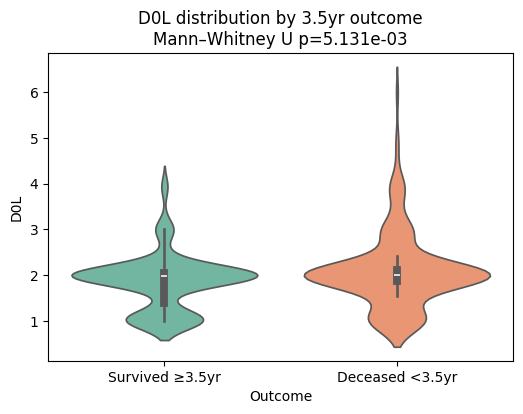

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


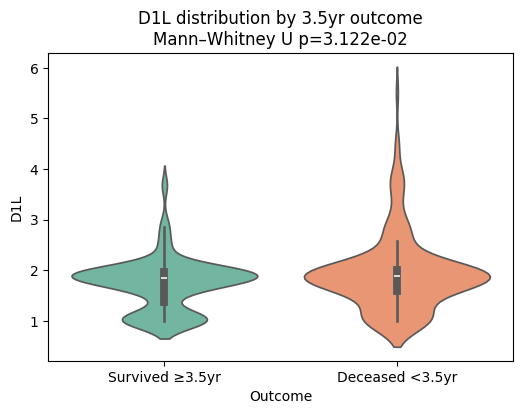

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


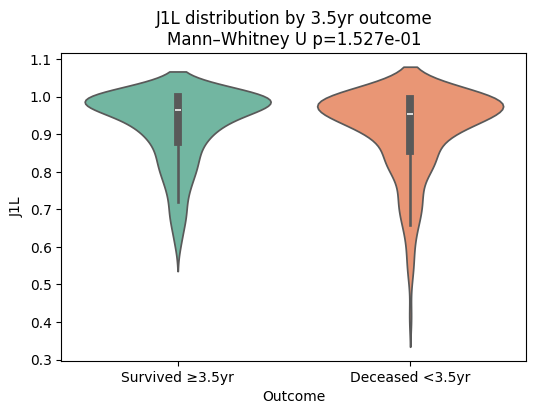

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


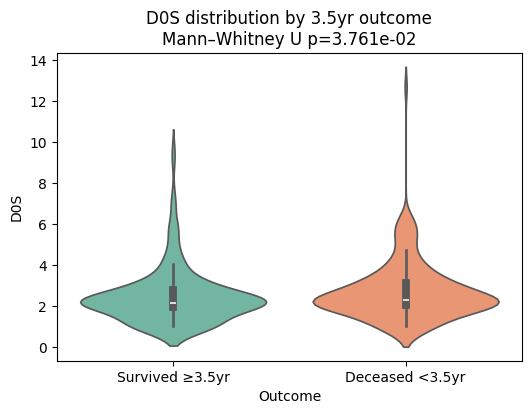

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


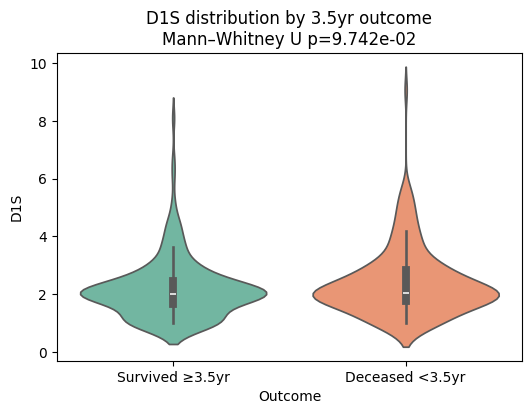

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


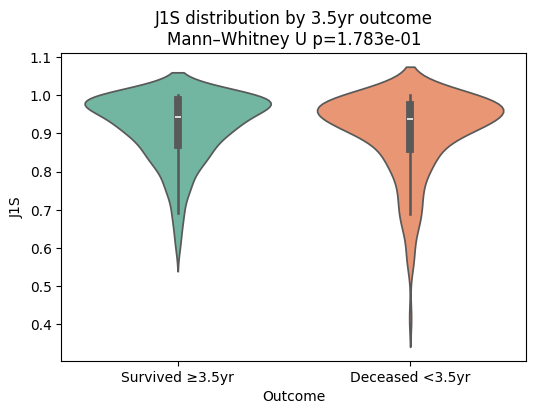

In [15]:
from scipy.stats import mannwhitneyu

for idx in index_cols:
    # Split values by group
    group0 = df.loc[df["os_event"] == 0, idx].dropna()
    group1 = df.loc[df["os_event"] == 1, idx].dropna()

    # Mann–Whitney U test
    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")

    # Plot violin/box
    plt.figure(figsize=(6,4))
    sns.violinplot(
        data=df,
        x="os_event",
        y=idx,
        inner="box",
        palette="Set2"
    )
    plt.xticks([0,1], ["Survived ≥3.5yr", "Deceased <3.5yr"])
    plt.title(f"{idx} distribution by 3.5yr outcome\nMann–Whitney U p={p:.3e}")
    plt.ylabel(idx)
    plt.xlabel("Outcome")
    plt.show()

In [16]:
# Mann-Whitney + FDR to prevent false positives

from statsmodels.stats.multitest import multipletests

results = []
for idx in index_cols:
    group0 = df.loc[df["os_event"] == 0, idx].dropna()
    group1 = df.loc[df["os_event"] == 1, idx].dropna()
    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")
    results.append({"index": idx, "U_stat": stat, "p_raw": p})

# Adjust p-values with Benjamini–Hochberg (FDR)
pvals = [r["p_raw"] for r in results]
reject, p_adj, _, _ = multipletests(pvals, method="fdr_bh")

for i, r in enumerate(results):
    r["p_adj_FDR"] = p_adj[i]
    r["significant"] = reject[i]

# Save results to CSV
results_df = pd.DataFrame(results)
results_df.to_csv("mannwhitney_results.csv", index=False)
print(results_df)

  index   U_stat     p_raw  p_adj_FDR  significant
0   D0N  15579.0  0.009631   0.043340         True
1   D1N  16270.0  0.050861   0.091550        False
2   J1N  19841.5  0.181924   0.181924        False
3   D0L  15351.0  0.005131   0.043340         True
4   D1L  16051.0  0.031219   0.084615        False
5   J1L  19945.0  0.152708   0.181924        False
6   D0S  16132.5  0.037607   0.084615        False
7   D1S  16590.5  0.097420   0.146129        False
8   J1S  19854.0  0.178328   0.181924        False


| Index   | Raw p-value | FDR q-value | Significant (q < 0.05)? | Interpretation                                                         |
| ------- | ----------- | ----------- | ----------------------- | ---------------------------------------------------------------------- |
| **D0N** | 0.0096      | 0.0433      | ✅ Yes                   | Distribution differs between survivors vs deceased (robust after FDR). |
| D1N     | 0.0509      | 0.0916      | ❌ No                    | Suggestive, but not significant after correction.                      |
| J1N     | 0.1819      | 0.1819      | ❌ No                    | No evidence of difference.                                             |
| **D0L** | 0.0051      | 0.0433      | ✅ Yes                   | Strong evidence of difference, significant after FDR.                  |
| D1L     | 0.0312      | 0.0846      | ❌ No                    | Raw p < 0.05 but not significant after FDR.                            |
| J1L     | 0.1527      | 0.1819      | ❌ No                    | Not significant.                                                       |
| D0S     | 0.0376      | 0.0846      | ❌ No                    | Borderline raw p but not FDR significant.                              |
| D1S     | 0.0974      | 0.1461      | ❌ No                    | Not significant.                                                       |
| J1S     | 0.1783      | 0.1819      | ❌ No                    | Not significant.                                                       |


>* We now know D0N and D0L remain significant even after correcting for multiple comparisons.
>* These indices are robustly different between patients who survived ≥ 3.5 years compared to those who died early.
>* The others (D1N, D1L, D0S, etc.) show some signal at raw p<0.05, but don’t survive FDR adjustment → could be noise or require larger sample size.


---



# SHAP importance

In [60]:
print(df.columns)

Index(['cruk_id', 'D0N', 'D1N', 'J1N', 'D0L', 'D1L', 'J1L', 'D0S', 'D1S',
       'J1S', 'tumour_id_muttable_cruk', 'tumour_id_per_patient', 'age', 'sex',
       'ethnicity', 'cigs_perday', 'years_smoking', 'packyears',
       'smoking_status_merged', 'is.family.lung', 'ECOG_PS', 'pathologyTNM',
       'pT_stage_per_patient', 'pN_stage_per_patient', 'LVI_per_patient',
       'PL_per_patient', 'margin_status_per_patient',
       'size_pathology_per_patient', 'Surgery_type', 'histology_lesion1',
       'histology_lesion1_merged', 'lesion1_sampled', 'histology_lesion2',
       'lesion2_sampled', 'histology_multi_full',
       'histology_multi_full_genomically.confirmed', 'LUAD_pred_subtype',
       'adjuvant_treatment_YN', 'adjuvant_treatment_given',
       'num_cycle_na.added', 'CHMPlatDgName_cleaned', 'CHMOthDgName_cleaned',
       'AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'Recurrence_time_use',
       'newPrim_time_use', 'first_dfs_any_event_rec.or.new.primary',
       'first_ev

In [64]:
# Exclude any markers related to outcome to prevent leaking info
id_cols = ["cruk_id", "tumour_id_muttable_cruk", "tumour_id_per_patient"]
outcome_cols = ["cens_os", "os_time", "dfs_time_any_event", "cens_dfs_any_event",
                "cens_lung_event", "lung_event_time", "Relapse_cat",
                "Recurrence_time_use", "Relapse_cat_new", "first_event_during_followup"]

# Exclude outcomes
covariates = [c for c in df.columns if c not in id_cols + outcome_cols]


In [72]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold

def prepare_cox_stable(df, duration_col="os_time", event_col="cens_os",
                       drop_high_missing=0.3, high_corr_threshold=0.99, verbose=True):
    """
    Prepares a dataframe for stable CoxPH fitting.

    Parameters:
        df (pd.DataFrame): original dataframe
        duration_col (str): time-to-event column
        event_col (str): event indicator column (1=event, 0=censor)
        drop_high_missing (float): fraction of missing above which columns are dropped
        high_corr_threshold (float): correlation threshold for dropping collinear features
        verbose (bool): print info about drops and transformations

    Returns:
        pd.DataFrame: cleaned dataframe ready for CoxPHFitter
        List[str]: final covariate names
    """
    df = df.copy()

    # Step 1: Identify outcome and ID columns
    outcome_cols = [
        duration_col, event_col, "dfs_time_any_event", "cens_dfs_any_event",
        "cens_lung_event", "lung_event_time", "Recurrence_time_use",
        "Relapse_cat", "Relapse_cat_new", "first_event_during_followup",
        "os_time", "os_event"
    ]
    id_cols = ["cruk_id", "tumour_id_muttable_cruk", "tumour_id_per_patient"]

    # Step 2: Drop high-missing columns
    missing_frac = df.isna().mean()
    drop_cols = missing_frac[missing_frac > drop_high_missing].index.tolist()
    df = df.drop(columns=drop_cols, errors='ignore')
    if verbose:
        print("Dropped high-missing columns:", drop_cols)

    # Step 3: Remove outcome and ID columns from covariates
    covariates = [c for c in df.columns if c not in outcome_cols + id_cols]
    cox_df = df[covariates].copy()
    cox_df[duration_col] = df[duration_col]
    cox_df[event_col] = df[event_col]

    # Step 4: One-hot encode categorical columns
    cat_cols = cox_df.select_dtypes(include=["object", "category"]).columns.tolist()
    if len(cat_cols) > 0:
        cox_df = pd.get_dummies(cox_df, columns=cat_cols, drop_first=True)
        if verbose:
            print("One-hot encoded columns:", cat_cols)

    # Step 5: Fill missing numeric values
    num_cols = cox_df.select_dtypes(include=["number"]).columns.tolist()
    cox_df[num_cols] = cox_df[num_cols].fillna(cox_df[num_cols].median())

    # Step 6: Drop zero-variance columns
    selector = VarianceThreshold(threshold=1e-5)
    cox_df[num_cols] = selector.fit_transform(cox_df[num_cols])
    num_cols = cox_df.select_dtypes(include=["number"]).columns.tolist()

    # Step 7: Drop highly collinear columns
    corr_matrix = cox_df[num_cols].corr().abs()
    upper = corr_matrix.where(~np.tril(np.ones(corr_matrix.shape)).astype(bool))
    high_corr = [c for c in upper.columns if any(upper[c] > high_corr_threshold)]
    cox_df = cox_df.drop(columns=high_corr)
    if verbose and high_corr:
        print("Dropped highly collinear columns:", high_corr)

    # Step 8: Drop any remaining NaNs
    cox_df = cox_df.dropna()

    # Final covariates
    final_covariates = [c for c in cox_df.columns if c not in [duration_col, event_col]]
    if verbose:
        print(f"Final covariates ({len(final_covariates)}):", final_covariates)
        print("Dataframe ready for CoxPHFitter. Shape:", cox_df.shape)

    return cox_df, final_covariates


In [74]:
cox_df, covariates = prepare_cox_stable(df, duration_col="os_time", event_col="cens_os")

from lifelines import CoxPHFitter
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="os_time", event_col="cens_os")
cph.print_summary()


Dropped high-missing columns: ['histology_lesion2', 'lesion2_sampled', 'LUAD_pred_subtype', 'adjuvant_treatment_given', 'CHMPlatDgName_cleaned', 'CHMOthDgName_cleaned', 'AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'Recurrence_time_use', 'newPrim_time_use', 'first_dfs_any_event_rec.or.new.primary', 'first_event_during_followup', 'Relapse_cat']
One-hot encoded columns: ['sex', 'ethnicity', 'smoking_status_merged', 'pathologyTNM', 'pT_stage_per_patient', 'LVI_per_patient', 'PL_per_patient', 'margin_status_per_patient', 'Surgery_type', 'histology_lesion1', 'histology_lesion1_merged', 'histology_multi_full', 'histology_multi_full_genomically.confirmed', 'adjuvant_treatment_YN', 'os_event_label']
Final covariates (78): ['D0N', 'D1N', 'J1N', 'D0L', 'D1L', 'J1L', 'D0S', 'D1S', 'J1S', 'age', 'cigs_perday', 'years_smoking', 'packyears', 'is.family.lung', 'ECOG_PS', 'pN_stage_per_patient', 'size_pathology_per_patient', 'lesion1_sampled', 'num_cycle_na.added', 'cens_dfs', 'dfs_time', 'tx100',

/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:797: RuntimeWarning: invalid value encountered in divide
  return (X - mean) / std


ConvergenceError: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.

Top clinical features by SHAP importance:
| Rank | Feature                     | Importance | Group     |
|------|------------------------------|------------|-----------|
| 1    | cens_os                      | 0.095050   | Clinical  |
| 2    | cens_dfs_any_event           | 0.081789   | Clinical  |
| 3    | first_event_during_followup  | 0.069880   | Clinical  |
| 4    | cens_lung_event              | 0.043056   | Clinical  |
| 5    | lung_event_time              | 0.038122   | Clinical  |
| 6    | dfs_time_any_event           | 0.035696   | Clinical  |
| 7    | Relapse_cat                  | 0.031286   | Clinical  |
| 8    | Recurrence_time_use          | 0.030381   | Clinical  |
| 9    | Relapse_cat_new              | 0.021170   | Clinical  |
| 10   | os_time                      | 0.020986   | Clinical  |


In [21]:
from scipy.stats import spearmanr, mannwhitneyu, kruskal
import pandas as pd

clin_features = [
    "cens_os",
    "cens_dfs_any_event",
    "first_event_during_followup",
    "cens_lung_event",
    "lung_event_time",
    "dfs_time_any_event",
    "Relapse_cat",
    "Recurrence_time_use",
    "Relapse_cat_new",
    "os_time"
]

index_features = ["D0N", "D0L", "D1N", "D1L", "J1N"]

results = []

for b in clin_features:
    if b in df.columns:
        if pd.api.types.is_numeric_dtype(df[b]):
            # Numeric outcome → Spearman correlation
            for idx in index_features:
                r, p = spearmanr(df[idx], df[b], nan_policy="omit")
                results.append({
                    "ClinicalFeature": b,
                    "Index": idx,
                    "Test": "Spearman",
                    "Statistic": r,
                    "pval": p
                })
        else:
            # Categorical outcome
            groups = [g for _, g in df.groupby(b)]
            for idx in index_features:
                values = [g[idx].dropna() for g in groups]
                if len(groups) == 2:
                    stat, p = mannwhitneyu(values[0], values[1], alternative="two-sided")
                    test = "Mann–Whitney U"
                    stat_out = stat
                else:
                    stat, p = kruskal(*values)
                    test = "Kruskal–Wallis"
                    stat_out = stat
                results.append({
                    "ClinicalFeature": b,
                    "Index": idx,
                    "Test": test,
                    "Statistic": stat_out,
                    "pval": p
                })

results_df = pd.DataFrame(results)

# Sort by p-value
results_df = results_df.sort_values("pval").reset_index(drop=True)

Significant associations (p < 0.01)

       ClinicalFeature Index            Test  Statistic      pval
0      cens_lung_event   D0N        Spearman   0.193158  0.000140
1   dfs_time_any_event   D0N        Spearman  -0.190301  0.000176
2      lung_event_time   D0N        Spearman  -0.185300  0.000261
3   dfs_time_any_event   D0L        Spearman  -0.161033  0.001546
4      cens_lung_event   J1N        Spearman  -0.158361  0.001853
5      lung_event_time   D0L        Spearman  -0.156741  0.002066
6              os_time   D0N        Spearman  -0.153303  0.002594
7      Relapse_cat_new   D0N  Kruskal–Wallis  15.841654  0.003239
8              os_time   D0L        Spearman  -0.149497  0.003319
9   dfs_time_any_event   J1N        Spearman   0.146637  0.003980
10             cens_os   D0N        Spearman   0.144733  0.004484
11     cens_lung_event   D0L        Spearman   0.144632  0.004513
12     Relapse_cat_new   J1N  Kruskal–Wallis  14.778013  0.005184
13             cens_os   J1N        Spe

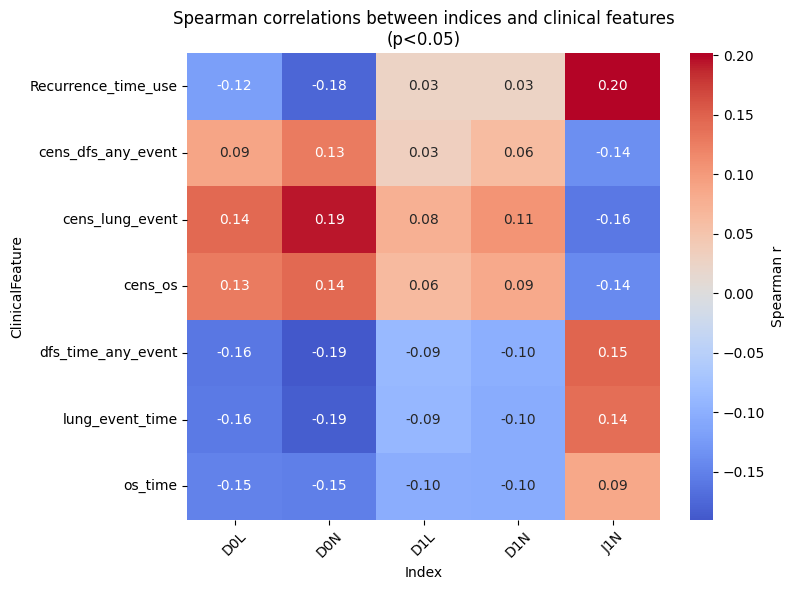

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter significant results (p < 0.01)
sig_results = results_df[results_df["pval"] < 0.01].sort_values("pval")


print("Significant associations (p < 0.01)\n")
print(sig_results)

# Heatmap: Spearman correlations only
corr_df = results_df[results_df["Test"]=="Spearman"].pivot(
    index="ClinicalFeature", columns="Index", values="Statistic"
)
pval_df = results_df[results_df["Test"]=="Spearman"].pivot(
    index="ClinicalFeature", columns="Index", values="pval"
)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_df, annot=True, cmap="coolwarm", center=0,
    mask=corr_df.isna(), fmt=".2f", cbar_kws={"label": "Spearman r"}
)
plt.title("Spearman correlations between indices and clinical features\n(p<0.05)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

| Index | Direction of Association | Clinical Association                                                                 |
|-------|--------------------------|--------------------------------------------------------------------------------------|
| D0N   | Positive (↑)             | Higher values linked to more adverse events (shorter DFS/OS, lung events).           |
| D0L   | Positive (↑)             | Higher values linked to more adverse events (shorter DFS/OS, lung events).           |
| J1N   | Negative (↓)             | Negative correlation with survival features (e.g., `cens_os`, `cens_dfs_any_event`); imbalance may be prognostic. |
| D1N   | Weak/Inconsistent        | Moderate or inconsistent associations.                                                |
| D1L   | Weak/Inconsistent        | Moderate or inconsistent associations.                                                |

Numerical Categories

| Clinical Feature       | D0N        | D0L        | D1N        | D1L        | J1N        |
|------------------------|------------|------------|------------|------------|------------|
| cens_os                | ↑ ✅       | ↑ ✅       | ↑ ❌       | ↑ ❌       | ↓ ✅       |
| cens_dfs_any_event     | ↑ ✅       | ↑ ❌       | ↑ ❌       | ↑ ❌       | ↓ ✅       |
| first_event_during_followup | H?      | H?         | H?         | H?         | H?         |
| cens_lung_event        | ↑ ✅       | ↑ ✅       | ↑ ✅       | ↑ ❌       | ↓ ✅       |
| lung_event_time        | ↓ ✅       | ↓ ✅       | ↓ ✅       | ↓ ❌       | ↑ ✅       |
| dfs_time_any_event     | ↓ ✅       | ↓ ✅       | ↓ ✅       | ↓ ❌       | ↑ ✅       |
| Relapse_cat            | H?         | H?         | H?         | H?         | H?         |
| Recurrence_time_use    | ↓ ✅       | ↓ ❌       | ↑ ❌       | ↑ ❌       | ↑ ✅       |
| Relapse_cat_new        | H?         | H?         | H?         | H?         | H?         |
| os_time                | ↓ ✅       | ↓ ✅       | ↓ ✅       | ↓ ✅       | ↑ ❌       |

For categorical features we will use Kruskal–Wallis test instead of Mann–Whitney, to compare distributions across ≥3 groups.
>H? = Kruskal–Wallis suggested (categorical feature, not tested yet)

Multi-Class Categorical Features
| Clinical Feature       | D0N        | D0L        | D1N        | D1L        | J1N        |
|------------------------|------------|------------|------------|------------|------------|
| cens_os                | ↑ ✅       | ↑ ✅       | ↑ ❌       | ↑ ❌       | ↓ ✅       |
| cens_dfs_any_event     | ↑ ✅       | ↑ ❌       | ↑ ❌       | ↑ ❌       | ↓ ✅       |
| cens_lung_event        | ↑ ✅       | ↑ ✅       | ↑ ✅       | ↑ ❌       | ↓ ✅       |
| lung_event_time        | ↓ ✅       | ↓ ✅       | ↓ ✅       | ↓ ❌       | ↑ ✅       |
| dfs_time_any_event     | ↓ ✅       | ↓ ✅       | ↓ ✅       | ↓ ❌       | ↑ ✅       |
| Relapse_cat            | —          | —          | —          | —          | H+ ✅      |
| Recurrence_time_use    | ↓ ✅       | ↓ ❌       | ↑ ❌       | ↑ ❌       | ↑ ✅       |
| Relapse_cat_new        | —          | —          | —          | —          | H+ ✅      |
| os_time                | ↓ ✅       | ↓ ✅       | ↓ ✅       | ↓ ✅       | ↑ ❌       |

# Survival Modeling
Using Cox proportional hazards

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler

In [88]:
# Example columns — change as needed
duration_col = "os_time"        # time-to-event column
event_col = "cens_os"          # event indicator (1=event, 0=censor)

# Indices & other covariates
index_features = ["D0N","D0L","D1N","D1L","J1N"]
clin_covariates = ["age", "cigs_perday", "packyears", "years_smoking"]

# Build feature list; only keep columns that exist in df
features = [f for f in index_features + clin_covariates if f in df.columns]

# Drop rows with missing outcome
model_df = df.dropna(subset=[duration_col, event_col]).copy()
model_df = model_df.dropna(subset=features)

# One-hot encode categorical covariates
cat_cols = model_df[features].select_dtypes(include=["object","category"]).columns.tolist()
if len(cat_cols) > 0:
    model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

# Update features after dummy encoding
features = [c for c in model_df.columns if c not in [duration_col, event_col] and c in (index_features + clin_covariates or []) or c.startswith(tuple(cat_cols))]

# Standardize numeric features (recommended for interpretation when regularizing)
num_cols = [c for c in features if pd.api.types.is_numeric_dtype(model_df[c])]
scaler = StandardScaler()
model_df[num_cols] = scaler.fit_transform(model_df[num_cols])

In [89]:
cph = CoxPHFitter(penalizer=0.0)   # set penalizer>0 for ridge penalty if desired
cph.fit(model_df[[duration_col, event_col] + features], duration_col=duration_col, event_col=event_col, show_progress=True)
cph.print_summary()   # shows coef, exp(coef) = HR, se, z, p, CI


Iteration 1: norm_delta = 5.06e+00, step_size = 0.9500, log_lik = -889.30649, newton_decrement = 1.79e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 4.09e+00, step_size = 0.2375, log_lik = -881.82172, newton_decrement = 1.03e+01, seconds_since_start = 0.0
Iteration 3: norm_delta = 3.03e+00, step_size = 0.3087, log_lik = -876.44369, newton_decrement = 4.89e+00, seconds_since_start = 0.0
Iteration 4: norm_delta = 1.62e+00, step_size = 0.5218, log_lik = -872.66948, newton_decrement = 1.12e+00, seconds_since_start = 0.0
Iteration 5: norm_delta = 2.53e-01, step_size = 0.8818, log_lik = -871.56180, newton_decrement = 1.77e-02, seconds_since_start = 0.0
Iteration 6: norm_delta = 1.51e-03, step_size = 1.0000, log_lik = -871.54403, newton_decrement = 6.67e-07, seconds_since_start = 0.0
Iteration 7: norm_delta = 1.37e-07, step_size = 1.0000, log_lik = -871.54403, newton_decrement = 7.06e-15, seconds_since_start = 0.0
Convergence success after 7 iterations.


<lifelines.CoxPHFitter: fitted with 384 total observations, 224 right-censored observations>
             duration col = 'os_time'
                event col = 'cens_os'
      baseline estimation = breslow
   number of observations = 384
number of events observed = 160
   partial log-likelihood = -871.54
         time fit was run = 2025-09-23 23:16:43 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
D0N            2.49     12.12      2.81           -3.01            8.00                0.05             2981.71
D1N           -2.38      0.09      3.06           -8.38            3.63                0.00               37.69
J1N           -0.31      0.73      0.16           -0.62            0.00                0.54                1.00
D0L           -3.13      0.04      2.83           -8.68            2.42                0.00               11.21
D1L            3.21     24.69      3.09           -2.84            9.25                0.06            10454.68
age            0.27      1.31      0.09            0.10            0.45                1.10                1.56
cigs_perday    0.51      1.66      0.20            0.12            0.90                1.13                2.45
years_smoking  0.27      1.31      0.13            0.01            0.52                1.01                1.69
packyears     -0.52      0.60      0.24           -0.99           -0.04                0.37                0.96

               cmp to     z      p  -log2(p)
covariate                                   
D0N              0.00  0.89   0.37      1.42
D1N              0.00 -0.78   0.44      1.19
J1N              0.00 -1.94   0.05      4.25
D0L              0.00 -1.11   0.27      1.90
D1L              0.00  1.04   0.30      1.74
age              0.00  3.07 <0.005      8.88
cigs_perday      0.00  2.56   0.01      6.58
years_smoking    0.00  2.06   0.04      4.66
packyears        0.00 -2.14   0.03      4.93
---
Concordance = 0.64
Partial AIC = 1761.09
log-likelihood ratio test = 35.52 on 9 df
-log2(p) of ll-ratio test = 14.34

In [90]:
pred_risk = cph.predict_partial_hazard(model_df[features])
c_index = concordance_index(model_df[duration_col], -pred_risk, model_df[event_col])  # negative if higher risk -> shorter survival
print("Concordance index (C-index):", c_index)

Concordance index (C-index): 0.6354103240646777


               test_statistic         p  -log2(p)
D0L                  0.133449  0.714883  0.484222
D0N                  0.510051  0.475117  1.073646
D1L                  0.135101  0.713201  0.487620
D1N                  0.469432  0.493249  1.019613
J1N                  2.285184  0.130615  2.936611
age                  1.463980  0.226298  2.143705
cigs_perday          0.048375  0.825916  0.275934
packyears            0.375386  0.540083  0.888747
years_smoking        0.000018  0.996573  0.004953

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional h

[[<Axes: xlabel='rank-transformed time\n(p=0.4751)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4505)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4932)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4716)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1306)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1054)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7149)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6947)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7132)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6985)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2263)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2293)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8259)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8948)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9966)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9057)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5401)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5934)'>]]

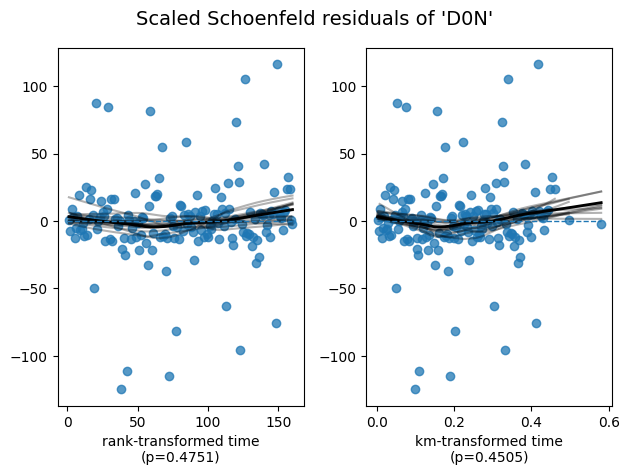

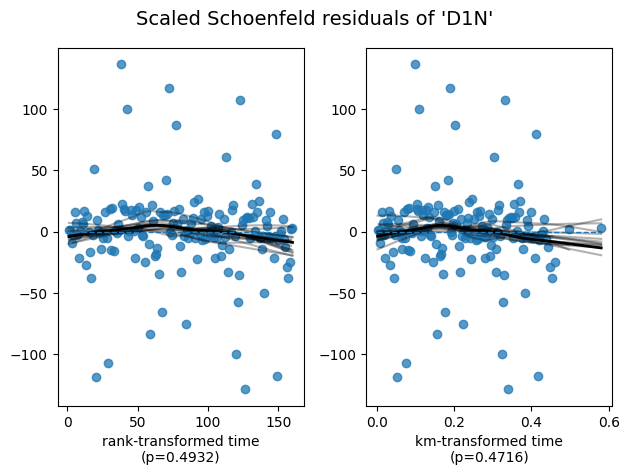

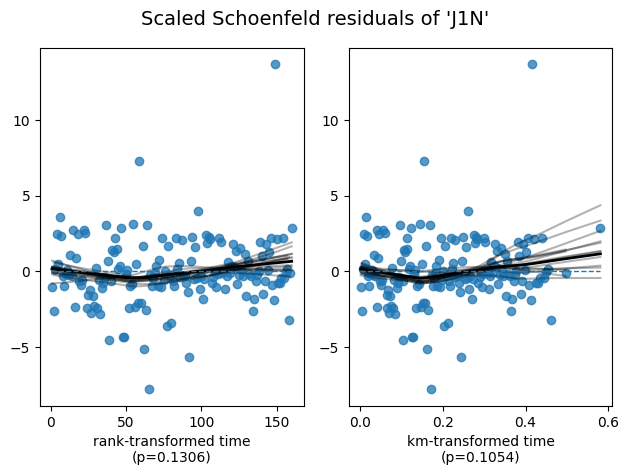

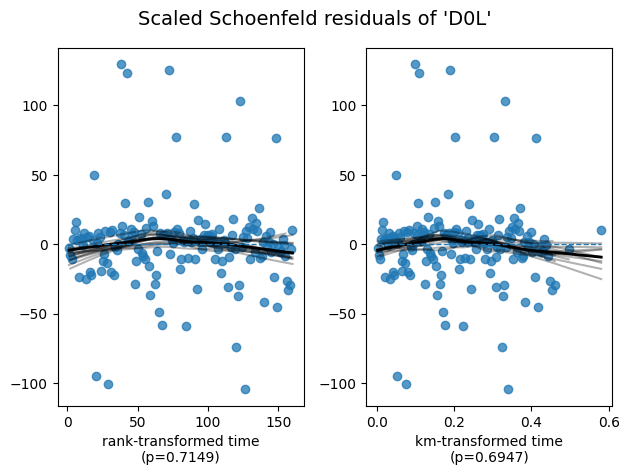

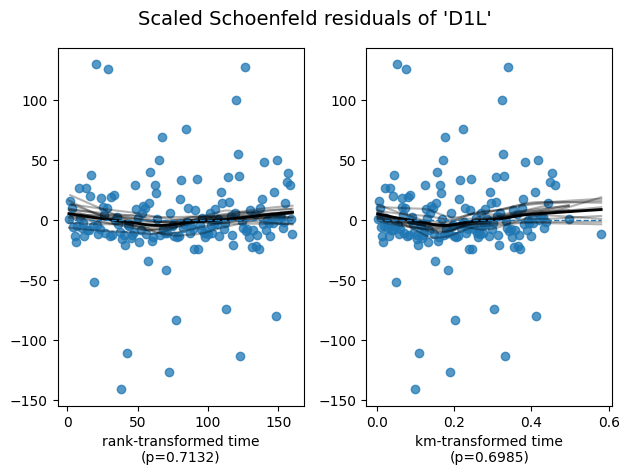

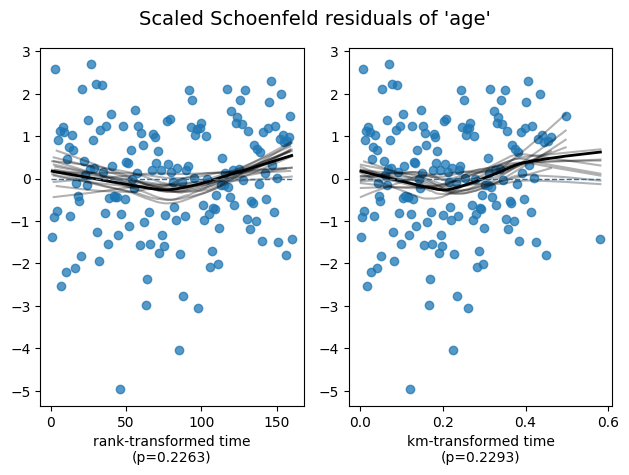

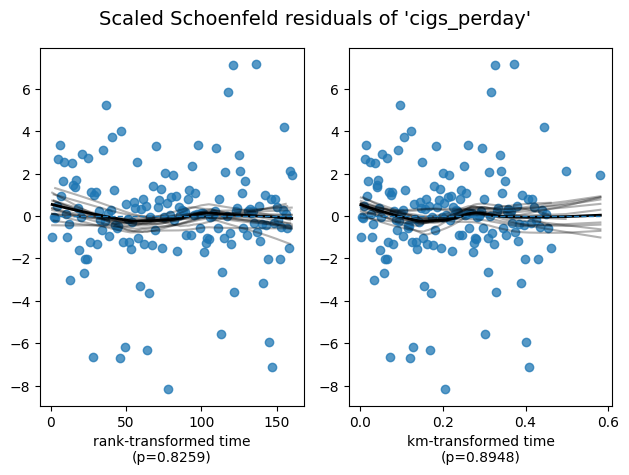

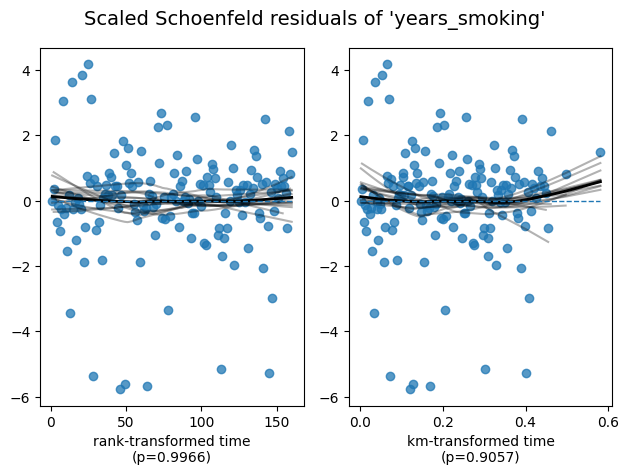

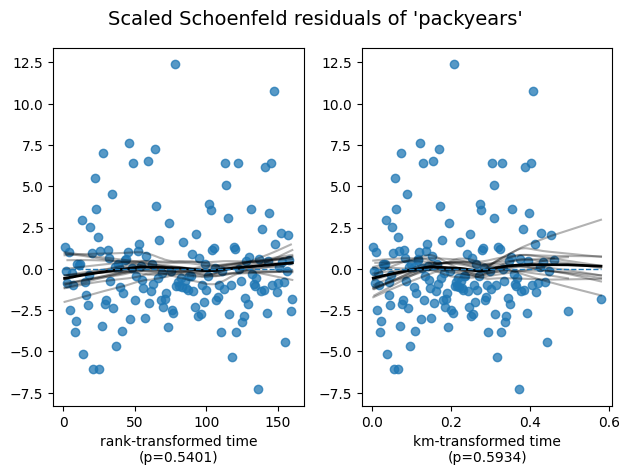

In [92]:
from lifelines.statistics import proportional_hazard_test

# Test globally and per-covariate (uses scaled Schoenfeld residuals)
res = proportional_hazard_test(cph, model_df[[duration_col, event_col] + features], time_transform='rank')  # 'rank' is a common choice
print(res.summary)  # check p-values; small p => violation

# Quick manual: lifelines CoxPHFitter has check_assumptions (plots and suggestions)
cph.check_assumptions(model_df[[duration_col, event_col] + features], p_value_threshold=0.01, show_plots=True) # set show_plots=True to inspect residual plots

# Interpret biologically and Integrate with treatment response

In [114]:
# Push on git
!git config --global user.name "szinja"
!git config --global user.email "szinja@u.rochester.edu"


!git add .
!git commit -m "Adding Cox Model"

fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [115]:
!git status

fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [116]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/'Colab Notebooks'/
%ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks
 cell-translation/                           final_model.ipynb
'Copy of 2026_Scholar_Takehome_Exam.ipynb'   test.ipynb


In [117]:
!mv "/content/drive/MyDrive/'Colab Notebooks'/final_model.ipynb" "/content/drive/MyDrive/'Colab Notebooks'/cell-translation/final_model.ipynb"

mv: cannot stat "/content/drive/MyDrive/'Colab Notebooks'/final_model.ipynb": No such file or directory


In [111]:
!git add final_model.ipynb
!git commit -m "Add Colab notebook from Drive"

fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
